In [50]:
import os

RANDOM_STATE = 42
N_JOBS = int(os.cpu_count() * .75)
N_TRIALS = 300

In [51]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

bc = load_breast_cancer()
print(bc.keys())

df = pd.DataFrame(bc.data, columns=bc.feature_names)
target = pd.Series(bc.target)

print(df.info())

print(target.value_counts())


dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null

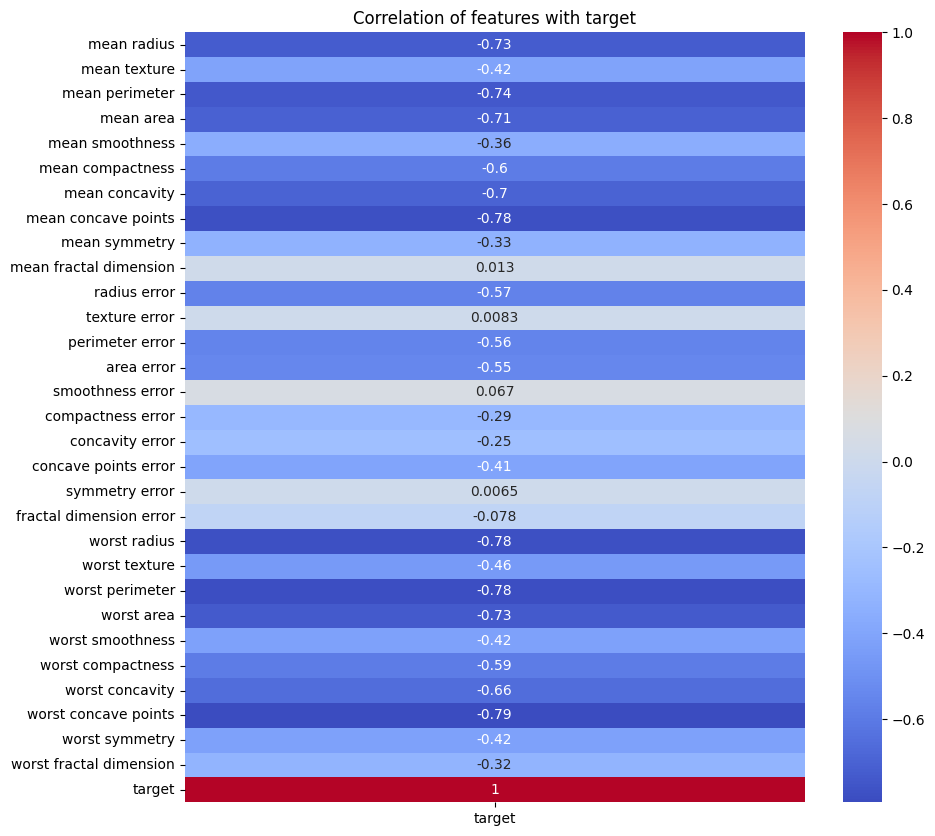

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

df['target'] = target

plt.figure(figsize=(10, 10))
sns.heatmap(df.corr()['target'].to_frame(), annot=True, cmap='coolwarm')
plt.title('Correlation of features with target')
plt.show()
plt.close()


In [53]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['target'])
Y = df['target']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3,stratify=Y, random_state=RANDOM_STATE)

In [54]:
from xgboost import XGBClassifier
import optuna 
from sklearn.metrics import make_scorer, fbeta_score
from sklearn.model_selection import cross_val_score

scorer = make_scorer(fbeta_score, beta=2, pos_label=1)

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True), 
        'max_depth': trial.suggest_int('max_depth', 3, 10), 
        'n_estimators': trial.suggest_int('n_estimators', 200, 750), 
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),    
        'colsample_bynode': trial.suggest_float('colsample_bynode', 0.5, 1.0), 
        'min_child_weight': trial.suggest_int('min_child_weight', 2, 20), 
        'gamma': trial.suggest_float('gamma', 0.0, 5.0), 
        'reg_alpha': trial.suggest_float('reg_alpha', 0.1, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 10.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 15.0),
        'n_jobs': N_JOBS,
        'random_state': RANDOM_STATE
    }

    model = XGBClassifier(**params)
    return cross_val_score(model, x_train, y_train, cv=5, scoring=scorer).mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
print(study.best_params)

Best trial: 238. Best value: 0.992873: 100%|██████████| 300/300 [04:38<00:00,  1.08it/s]

{'learning_rate': 0.024158082288352613, 'max_depth': 5, 'n_estimators': 740, 'subsample': 0.5517222429400551, 'colsample_bytree': 0.6001742873950046, 'colsample_bylevel': 0.80406601306881, 'colsample_bynode': 0.9404987594856222, 'min_child_weight': 3, 'gamma': 1.0837576566653657, 'reg_alpha': 0.3025324976571211, 'reg_lambda': 0.6385318665837637, 'scale_pos_weight': 14.960567870599876}


In [55]:
from sklearn.metrics import classification_report

xgb = XGBClassifier(**study.best_params, random_state = RANDOM_STATE, n_jobs = -1)
xgb.fit(x_train, y_train)

print('='*30, 'TRAIN', '='*30)
print(classification_report(y_train, xgb.predict(x_train)))
print('')
print('='*30, 'TEST', '='*30)
print(classification_report(y_test, xgb.predict(x_test)))

============================== TRAIN ==============================
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       148
           1       0.98      1.00      0.99       250

    accuracy                           0.98       398
   macro avg       0.99      0.98      0.98       398
weighted avg       0.99      0.98      0.98       398


============================== TEST ==============================
              precision    recall  f1-score   support

           0       1.00      0.89      0.94        64
           1       0.94      1.00      0.97       107

    accuracy                           0.96       171
   macro avg       0.97      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



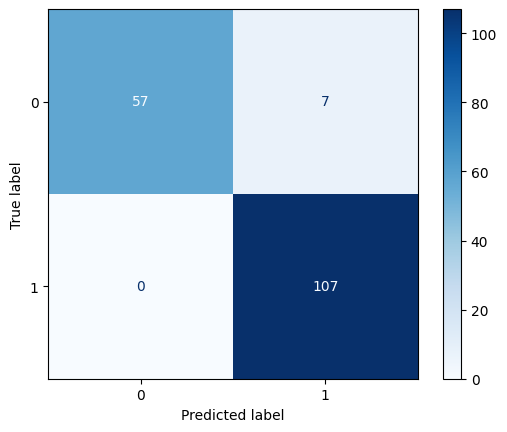

In [56]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(xgb, x_test, y_test, cmap='Blues')